# Hands-on with Python

- Este colab contém uma aula prática sobre:
    - Soluções sobre problemas de regressão;
    - Sanitização de dados;
    - Manipulação de dados

- Usaremos os seguintes módulos escritos em Python:
    - Sci-Kit Learn
    - Plotly
    - pandas
    - numpy

In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
url = ('https://raw.githubusercontent.com/skandarblue/MLCC/main/bmw.csv')
df = pd.read_csv(url)

Conhecer a base de dados é um passo importante para entender o que está sendo trabalhado. As 3 funções abaixo trazem visualizações importantes para entender o espectro do seu DataFrame.

In [ ]:
df.shape[0]

In [ ]:
df.info()

In [ ]:
df['transmission'].value_counts()

In [ ]:
tipo = {
    "Automatic": 1,
    "Manual": 0,
    "Semi-Auto": 0.5
}

df['transmission'] = df['transmission'].map(tipo)

Em casos onde dados são estritamente categóricos e únicos para cada instância (ID, Nome), é necessário excluir a coluna para realizar outras operações.

Neste caso abaixo, serão excluídas duas colunas que são categóricas mas poderiam ser transformadas em valores numéricos caso houvesse um maior conhecimento do domínio.

In [ ]:
df4 = df.drop(['model', 'fuelType'], axis=1)

In [ ]:
df.info()

#Matriz de correlação

Um dos pontos principais ao entender a sua base de dados é compreender como ela interage com a sua classe de saída.

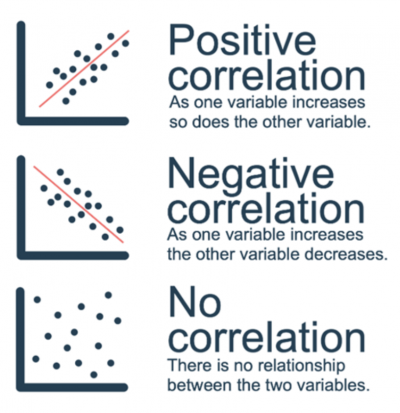


Idealmente, aquelas classes que possuem uma **correlação inversa ou direta** (-1 ou 1) com a coluna de saída são as mais influentes no meu problema de regressão.

In [ ]:
df

In [ ]:
df.corr(numeric_only=True)

#Checando por Outliers

Em muitos casos, outliers podem afetar drasticamente a performance do nosso regressor. Por isso, existem algumas práticas que podem ser realizadas para retirar esses outliers.

##BoxPlot
É uma maneira prática de visualizar outliers. O módulo plotly.express rapidamente calcula a partir de que ponto os valores começam a ser reconhecidos como outliers*.

*: Em alguns casos, a natureza da base de dados precisa que valores mais altos sejam mantidos.

##Fórmula com quartis/amplitude

Prática comum para manipulação de dados. Este cálculo retira valores que sempre estarão desproporcionalmente mais altos. Boa prática para encontrar ruídos muito discrepantes.

Para melhor entendimento, quartis são as divisões em valor da base de dados. Considerando uma coluna com valores numéricos, se faz a ordenação e divide-se em quartis. Q1, ou lower quartile, representam os 25% primeiros valores. Q2 é representado da mediana para baixo. Q3 são os 75% primeiros valores. O método ".quantile" te permite utilizar outros valores.

In [ ]:
fig = px.box(df, y="price")
fig.show()

In [ ]:
def getoutliersvalue(xs):
  outliers = []
  if xs in df.columns:
    ql = df[xs].quantile([.25, .75])
    amplitude = ql.iloc[1] - ql.iloc[0]
    moderateout = ql.iloc[1] + (amplitude*1.5)
    extremeout = ql.iloc[1] + (amplitude*3.0)
    outliers.append(moderateout)
    outliers.append(extremeout)
    return outliers

In [ ]:
getoutliersvalue("price")

#Regressão Linear

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [ ]:
url = ("https://github.com/ybifoundation/Dataset/raw/main/Salary%20Data.csv")
salario = pd.read_csv(url)

In [ ]:
salario.head()

O SciKit-learn naturalmente exige que a base de entrada seja no mínimo 2-D, mesmo se tratando de um problema de regressão linear simples. Por isso, é necessário que X seja declarado dentro de uma lista.

In [ ]:
X = salario[['Experience Years']]
y = salario['Salary']


Tradicionalmente, utiliza-se da divisão 70/30 ou 80/20 para treinar um modelo. Existem outras estratégias mais robustas de validação cruzada que são recomendadas para base de dados mais complexas, como K-Fold.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=25)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train,y_train)

Abaixo estão os valores de intercepto ou theta0 e theta1.

In [ ]:
model.intercept_

In [ ]:
model.coef_

A função abaixo vai agora predizer qual o valor de y dado um valor de X não visto antes.

In [ ]:
y_pred = model.predict(X_test)

Abaixo estão as funções de custo de ambas métricas, MAE e MAPE. Na maioria das vezes, o MAPE é mais interpretável e normalmente preferível, mas não traz o valor residual real, onde em alguns casos pode ser necessário.

In [ ]:
mean_absolute_error(y_test,y_pred)

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

#Regressão Múltipla

In [ ]:
url = ('https://github.com/YBIFoundation/Dataset/raw/main/Boston.csv')
boston = pd.read_csv(url)

Caso você queira estudar em casa e utilizar outros algoritmos de regressão, o vídeo abaixo explica o que cada coluna representa:

https://youtu.be/vsAzc7GvQSs

In [ ]:
boston.describe()

In [ ]:
boston.corr()

Ao invés de utilizar o .drop com inplace, você pode simplesmente declarar a variável sem as colunas que pretende utilizar. É uma prática preferível se você ainda está experimentando.

In [ ]:
y = boston['MEDV']
X = boston.drop(['MEDV'], axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=3)

Método para checar se as divisões estão proporcionais ao que é esperado da base de dados.

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

In [ ]:
model.intercept_

In [ ]:
mean_absolute_error(y_pred,y_test)

#Regressão Logística

Por se tratar de um problema de classificação, as métricas de acurácia também se tornam diferentes. Além da acurácia, existem outras métricas de avaliação da predição.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
url = ("https://raw.githubusercontent.com/skandarblue/MLCC/main/data.csv")
base = pd.read_csv(url)
base

Observando a base de dados, é possível notar duas observações que devem ser analisadas antes do algoritmo ser aplicado. O id é uma coluna que não trará valor substancial para o nosso classificador, portanto, deve ser retirado. Além disso, há uma coluna com valores não-existentes, ela também deve ser retirada.

In [ ]:
base.info()

In [ ]:
y = base['diagnosis']

In [ ]:
X = base.drop(['id','diagnosis', "Unnamed: 32"], axis=1)

In [ ]:
X

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

In [ ]:
classifier = LogisticRegression(random_state = 0, max_iter=5000)
classifier.fit(X_train, y_train)

In [ ]:
train_predictions = classifier.predict(X_train)
test_predictions = classifier.predict(X_test)

Quanto maior a acurácia, mais acertos o algoritmo de regressão logística teve.

In [ ]:
print("Acurácia dos dados de treino",accuracy_score(y_train,train_predictions))

In [ ]:
print("Acurácia dos dados de teste",accuracy_score(y_test,test_predictions))

#Random Forest Regressor

Nesta seção, será mostrada uma base de dados que procura predizer o valor do ouro baseado em métricas numéricas. Todos os dados já estão limpos e sem valor nulo.

O módulo seaborn será utilizado para fazer uma melhor visualização da matriz de correlação.
O módulo metrics mostrará o R², uma das métricas melhor interpretáveis em problemas de regressão.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
from sklearn import metrics

In [ ]:
url = ("https://raw.githubusercontent.com/skandarblue/MLCC/main/gld_price_data.csv")
gold = pd.read_csv(url)
gold

Neste caso, a coluna data não oferecerá valor algum para o nosso preditor. Portanto, será removido. Porém, em análises de dados com ênfase em suas mudanças temporais, esta coluna pode ser muito importante.

In [ ]:
gold = gold.drop(['Date'], axis=1)

Visualização da matriz de correlação. É preferível em casos onde hajam muitas colunas para entendermos melhor quais as melhores correlações na base de dados.

In [ ]:
sns.heatmap(gold.corr(), cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8})

In [ ]:
X = gold.drop(['GLD'],axis=1)
y = gold['GLD']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=432)

In [ ]:
rf_regressor = RandomForestRegressor(n_estimators=100)
rf_regressor.fit(X_train, y_train)

In [ ]:
y_pred = rf_regressor.predict(X_test)

In [ ]:
score = metrics.r2_score(y_test, y_pred)

R2 é uma métrica muito utilizada para definir a eficácia de um preditor. O valor varia de 0 a 1, onde 1 é a predição perfeita.

In [ ]:
print("Determinação do R2: ", score)